In [1]:
## Import the necessary library for reading the file.
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
from dask.distributed import Client
import dask.array as da
#import h5netcdf
#import netCDF4

In [ ]:
## Module load 
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from typing import Union, List, Tuple

## Function to subset any given geofabric upstream of list of outlets
def subset_upstream_basins_shapefile(
    input_basin_path: str,
    input_river_path: str,
    start_ranks: Union[int, float, List[int], np.ndarray, pd.Series],
    rank_id_col: str,
    next_id_col: str,
    unit_area_col: str,
    upstream_area_col: str,
    output_basin_path: str,
    output_river_path: str,
    include_downstream: bool = False
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Subset upstream basins from a GeoFabric based on outlet rank IDs.
    Optionally includes the immediate downstream basin(s) and updates their upstream area.

    Parameters:
        input_basin_path (str): Path to input basin shapefile.
        input_river_path (str): Path to input river shapefile.
        start_ranks: Outlet rank(s) to start upstream search (int, list, np.ndarray, or Series).
        rank_id_col (str): Column name for basin ID.
        next_id_col (str): Column name for downstream ID.
        unit_area_col (str): area of the subbasin.
        upstream_area_col (str): Column to update with total upstream area.
        output_basin_path (str): Path to save output basin shapefile.
        output_river_path (str): Path to save output river shapefile.
        include_downstream (bool): Include immediate downstream basin(s) and update area.

    Returns:
        Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]: Subsetted basin and river GeoDataFrames.
    """
    gdf_basin = gpd.read_file(input_basin_path).copy()
    gdf_river = gpd.read_file(input_river_path).copy()

    # Merge operation to join attribute table from input_river into input_basin
    missing_cols = [col for col in gdf_river.columns if col not in gdf_basin.columns[1:]]
    gdf_basin = gdf_basin.merge(gdf_river[missing_cols].copy(), on='COMID', how='left') 

    # Validate required columns
    required_cols = [rank_id_col, next_id_col, upstream_area_col, unit_area_col]    
    missing_cols = [col for col in required_cols if col not in gdf_basin.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s) in basin shapefile: {', '.join(missing_cols)}")

    # Normalize start_ranks
    if isinstance(start_ranks, (int, float)):
        start_ranks = [int(start_ranks)]
    elif isinstance(start_ranks, (np.ndarray, pd.Series)):
        start_ranks = start_ranks.astype(int).tolist()
    elif isinstance(start_ranks, list):
        start_ranks = list(map(int, start_ranks))
    else:
        raise TypeError(f"Unsupported type for start_ranks: {type(start_ranks).__name__}")

    # Build maps
    downstream_map = gdf_basin.set_index(rank_id_col)[next_id_col].to_dict()
    upstream_map = (
        gdf_basin[[rank_id_col, next_id_col]]
        .dropna()
        .groupby(next_id_col)[rank_id_col]
        .apply(list)
        .to_dict()
    )

    # Determine true outlet basins
    start_set = set(start_ranks)
    nested_outlets = {r for r in start_set if downstream_map.get(r) in start_set}
    true_outlets = start_set - nested_outlets
    if not true_outlets:
        raise ValueError("No valid outlets found (possibly circular or nested relationships).")

    # Traverse upstream
    visited = set()
    stack = list(true_outlets)
    while stack:
        current = stack.pop()
        if current not in visited:
            visited.add(current)
            stack.extend(upstream_map.get(current, []))

    downstream_ids = []

    if include_downstream:
        # Add immediate downstream(s) if not already included
        downstream_ids = [
            downstream_map[o] for o in true_outlets
            if downstream_map.get(o) not in visited and downstream_map.get(o) is not None
        ]
        visited.update(downstream_ids)

        # Update next_id_col to mark outlet point
        gdf_basin.loc[gdf_basin[rank_id_col].isin(downstream_ids), next_id_col] = -9999

        # Update upstream area of downstream basins
        for outlet in true_outlets:
            downstream_id = downstream_map.get(outlet)
            if downstream_id in downstream_ids:
                try:
                    outlet_area = gdf_basin.loc[gdf_basin[rank_id_col] == outlet, upstream_area_col].values[0]
                    unit_area = gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, unit_area_col].values[0]
                    gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, upstream_area_col] = outlet_area + unit_area
                except IndexError:
                    continue
    else:
        gdf_basin.loc[gdf_basin[rank_id_col].isin(true_outlets), next_id_col] = -9999

    # Subset basin and river layers
    gdf_basin = gdf_basin[gdf_basin[rank_id_col].isin(visited)].copy()
    gdf_river = gdf_river[gdf_river[rank_id_col].isin(gdf_basin[rank_id_col])].copy()

    # Save to files
    os.makedirs(os.path.dirname(output_basin_path), exist_ok=True)
    gdf_basin.to_file(output_basin_path, driver='ESRI Shapefile')
    print(f"✅ Saved basin subset to: {output_basin_path}")

    os.makedirs(os.path.dirname(output_river_path), exist_ok=True)
    gdf_river.to_file(output_river_path, driver='ESRI Shapefile')
    print(f"✅ Saved river subset to: {output_river_path}")

    return gdf_basin, gdf_river
    
#######################################################################################################
## Function to subset input netcdf file for the study of interest
def subset_netcdf_ddb(
    input_basin_path,
    input_ddb_nc_path, 
    output_ddb_nc_path 
):
    # Load basin shapefile
    gdf = gpd.read_file(input_basin_path)
    print(f"Loaded basin shapefile with {len(gdf)} features")

    # Open DDB and reorder
    with xr.open_dataset(input_ddb_nc_path, chunks={}) as ds_ddb:
        rank_id_ddb = ds_ddb['Rank'].dropna(dim='subbasin').values.astype(int)
        next_id_ddb = ds_ddb['Next'].dropna(dim='subbasin').values.astype(int)
        comid_id_ddb = ds_ddb['subbasin'].dropna(dim='subbasin').values.astype(int)

        if 'Rank' in gdf.columns or 'Next' in gdf.columns:
            gdf.drop(columns=['Rank', 'Next'], inplace=True, errors='ignore')
        df = pd.DataFrame({'COMID': comid_id_ddb, 'Rank': rank_id_ddb, 'Next': next_id_ddb}).dropna().astype(int)
        gdf = gdf.merge(df, on='COMID', how='left')

#        if 'Rank' not in gdf.columns or 'Next' not in gdf.columns:
#            df = pd.DataFrame({'COMID': comid_id_ddb, 'Rank': rank_id_ddb, 'Next': next_id_ddb}).dropna().astype(int)
#            gdf = gdf.merge(df, on='COMID', how='left')
        
        if 'Next' not in gdf.columns:
            gdf['Next'] = np.nan

        gdf.loc[gdf['NextDownID'] == -9999.0, 'Next'] = 0
        gdf['Rank_int'] = gdf['Rank'].astype('Int64')
        gdf['Next_int'] = gdf['Next'].fillna(0).astype(int)

        outlet_ranks = gdf.loc[gdf['NextDownID'] == -9999.0, 'Rank_int'].dropna().tolist()
        non_outlet_ranks = gdf.loc[gdf['NextDownID'] != -9999.0, 'Rank_int'].dropna().tolist()
        reordered = np.concatenate([sorted(non_outlet_ranks), sorted(outlet_ranks)])
        reordered_list = list(reordered)

        rank_to_index_ddb = {r: i for i, r in enumerate(rank_id_ddb)}
        reordered_indices_ddb = [rank_to_index_ddb[r] for r in reordered if r in rank_to_index_ddb]

        subbasin_dim_ddb = 'subbasin' if 'subbasin' in ds_ddb.dims else list(ds_ddb.dims)[0]
        ds_ddb_subset = ds_ddb.isel({subbasin_dim_ddb: reordered_indices_ddb})

        subbasin_sub_ddb = ds_ddb_subset['subbasin'].values.astype(int) if 'subbasin' in ds_ddb_subset.coords else np.arange(len(reordered_indices_ddb))

        rank_map = {r: i + 1 for i, r in enumerate(reordered)}
        gdf_indexed = gdf.set_index('Rank_int')
        gdf_sub = gdf_indexed.loc[reordered]
        new_rank = np.array([rank_map[r] for r in reordered])
        new_next = np.array([rank_map.get(n, 0) for n in gdf_sub['Next_int'].values])

        ds_ddb_sub = ds_ddb_subset.assign_coords({subbasin_dim_ddb: np.arange(len(new_rank))})
        ds_ddb_sub = ds_ddb_sub.assign(
            Rank_old=(subbasin_dim_ddb, reordered),
            Next_old=(subbasin_dim_ddb, gdf_sub['Next_int'].values),
            subbasin=(subbasin_dim_ddb, subbasin_sub_ddb),
            Rank=(subbasin_dim_ddb, new_rank),
            Next=(subbasin_dim_ddb, new_next)
        ).sortby("Rank")

        if 'lat' in ds_ddb and 'lon' in ds_ddb:
            ds_ddb_sub = ds_ddb_sub.assign_coords(
                lat=ds_ddb['lat'].isel({subbasin_dim_ddb: reordered_indices_ddb}),
                lon=ds_ddb['lon'].isel({subbasin_dim_ddb: reordered_indices_ddb})
            )

        # Compute the maximum rank
        max_rank = ds_ddb_sub['Rank'].max()
        # Create a mask where Next == 0 and Rank != max_rank
        mask = (ds_ddb_sub['Next'] == 0) & (ds_ddb_sub['Rank'] != max_rank)
        # Update 'Next' where the mask is True
        ds_ddb_sub['Next'] = ds_ddb_sub['Next'].where(~mask, other=max_rank)
        # Save the updated dataset to a new file or overwrite the existing one
        ds_ddb_sub.to_netcdf(output_ddb_nc_path)  # or input_ddb_nc_path to overwrite

        print(f"Saved DDB subset to {output_ddb_nc_path}")

    return ds_ddb_sub
###################################################################################################

## Function to adjust the Next of all outlet other than the one with 
# the maximum Rank to flow into the Outlet with the maximum Rank
import xarray as xr

def move_one_subbasin_outlets_into_maxrank_outlet(
    input_ddb_nc,
    output_ddb_nc
):
    # Open the dataset in read/write mode
    with xr.open_dataset(input_ddb_nc) as ds_ddb:
        # Load the variables into memory if necessary
        ds_ddb.load()
        # Compute the maximum rank
        max_rank = ds_ddb['Rank'].max()
        # Create a mask where Next == 0 and Rank != max_rank
        mask = (ds_ddb['Next'] == 0) & (ds_ddb['Rank'] != max_rank)
        # Update 'Next' where the mask is True
        ds_ddb['Next'] = ds_ddb['Next'].where(~mask, other=max_rank)
        # Save the updated dataset to a new file or overwrite the existing one
        ds_ddb.to_netcdf(output_ddb_nc)  # or input_ddb_nc_path to overwrite
    return 

# Application of the domain specific script to add a pad-outlet to the existing MESH_drainage_database.nc files
#input_ddb_nc = os.path.join(directory1, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
#output_ddb_nc = os.path.join(directory1, "pad_MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
#move_one_subbasin_outlets_into_maxrank_outlet(input_ddb_nc, output_ddb_nc)
###################################################################################################

## Function to Subset the Parameters and Climate netcdf file
import xarray as xr
import numpy as np
import os

def ultra_fast_subset_preserve_order(
    input_nc_path,
    input_ddb_path,
    output_nc_path,
    dim_data="subbasin",
    dim_key="Rank_old",
    time_chunksize=10000,
):
    # Avoid HDF5 locking issues on shared filesystems
    os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

    # 1) Open without chunking indexed dimension
    data = xr.open_dataset(
        input_nc_path,
        chunks={"time": time_chunksize},
        lock=False,
        decode_cf=False,
    )

    # 2) Load mask
    mask = xr.open_dataset(input_ddb_path)

    # 3) Build index (ORDER PRESERVED)
    idx = mask[dim_key].values
    idx = idx[idx > 0].astype(np.int64) - 1

    # deduplicate WITHOUT sorting
    _, first = np.unique(idx, return_index=True)
    idx = idx[np.sort(first)]

    # 4) Fancy indexing — order is preserved
    subset = data.isel({dim_data: idx})

    # 5) Rechunk AFTER subsetting
    subset = subset.chunk(
        {
            "time": time_chunksize,
        }
    )

    # 6) Fast write
    encoding = {v: {"zlib": False} for v in subset.data_vars}

    subset.to_netcdf(output_nc_path, encoding=encoding)

    print("Done:", output_nc_path)


## Old-Function to Subset the Parameters and Climate netcdf file
import xarray as xr
import numpy as np

def subset_netcdf_climate_and_parameters(
    input_ddb_path,
    input_nc_path,
    output_nc_path,
    data_dim_name="subbasin",
    mask_dim_name="subbasin",
    key_column="Rank_old",
    lat_name="latitude",
    lon_name="longitude"
):
    """
    Subsets a NetCDF file using a mask file's Rank_old field.

    Parameters:
    - input_ddb_path: Path to the mask NetCDF file
    - input_nc_path: Path to the input data NetCDF file
    - output_nc_path: Path to save the subset data
    - data_dim_name: Name of the main data dimension to subset (default: "subbasin")
    - mask_dim_name: Name of the dimension in mask file (default: "subbasin")
    - key_column: Column in mask file that contains indices (default: "Rank_old")
    - lat_name: Latitude coordinate name in the data file (default: "latitude")
    - lon_name: Longitude coordinate name in the data file (default: "longitude")
    """
    # Load datasets, with chunking for the data NetCDF along the time dimension
    with xr.open_dataset(input_nc_path, chunks={"time": 100}) as data_nc, xr.open_dataset(input_ddb_path) as mask_nc:
        # Sort data along the 'subbasin' dimension (just in case it is not ordered)
        data_ids = data_nc[data_dim_name].values
        sort_idx = np.argsort(data_ids)
        data_sorted = data_nc.isel({data_dim_name: sort_idx})

        # Extract valid Rank_old indices from mask and convert to 0-based
        rank_ids = mask_nc[key_column].values.astype(int)
        valid_mask = rank_ids > 0
        selected_indices = rank_ids[valid_mask] - 1  # 0-based indexing

        # Subset data using selected indices
        subset = data_sorted.isel({data_dim_name: xr.DataArray(selected_indices, dims=mask_dim_name)})

        # Copy lat/lon coordinates from data
        subset = subset.assign_coords({
            lat_name: subset[lat_name],
            lon_name: subset[lon_name]
        })

        # Save to NetCDF
        subset.to_netcdf(output_nc_path)

    print(f"Subset saved to: {output_nc_path}")
    
    return 
#######################################################################################################

# Copy the required MESH input file
def edit_TotalNumOfGridsSubbasins_value(input_file_path, output_file_path, new_value):
        with open(input_file_path, 'r', encoding='utf-8') as src:
            lines = src.readlines()
            line = lines[3]
            # Preserve leading spaces/tabs
            leading_ws = line[:len(line) - len(line.lstrip())]
            # Split while preserving spacing logic
            tokens = line.strip().split()
            tokens[7] = str(new_value)
            # Rebuild the line with original indentation
            lines[3] = leading_ws + '   '.join(tokens) + '\n'
        with open(output_file_path, 'w', encoding='utf-8') as dest:
            dest.writelines(lines)


#######################################################################################################

# Function to extract the streamflow file for a given Stations ID
def extract_columns_with_header(input_file, column_names, output_file=None):
    with open(input_file, 'r') as f:
        lines = f.readlines()

    # Step 1: Extract full column list
    full_column_names = []
    for line in lines:
        if line.strip().startswith(':ColumnName'):
            full_column_names = line.strip().split()[1:]
            break

    if not full_column_names:
        raise ValueError("No ':ColumnName' line found.")

    # Map target names to indices
    col_indices = []
    for name in column_names:
        if name not in full_column_names:
            raise ValueError(f"Column '{name}' not found.")
        col_indices.append(full_column_names.index(name))

    # Step 2: Extract and reformat metadata
    in_colmeta = False
    metadata_dict = {}
    meta_order = []  # Preserve key order
    for line in lines:
        stripped = line.strip()
        if stripped == ':ColumnMetaData':
            in_colmeta = True
            continue
        elif stripped == ':EndColumnMetaData':
            in_colmeta = False
            continue
        elif in_colmeta:
            parts = line.strip().split()
            if not parts:
                continue
            key = parts[0]
            values = parts[1:]
            metadata_dict[key] = values
            meta_order.append(key)

    # Step 3: Extract header (lines before :ColumnMetaData)
    header_lines = []
    for line in lines:
        if line.strip() == ':ColumnMetaData':
            break
        header_lines.append(line)

    # Step 4: Extract data lines
    data_started = False
    data_lines = []
    for line in lines:
        if data_started:
            if line.strip() == '':
                continue
            parts = line.strip().split()
            selected = [parts[i] if i < len(parts) else '' for i in col_indices]
            data_lines.append(''.join(f"{val:>13}" for val in selected) + '\n')
        elif line.strip() == ':endHeader':
            data_started = True

    # Step 5: Reconstruct metadata block with formatting
    col_spacing = 13  # Same as original fixed width
    formatted_meta = []
    formatted_meta.append(':ColumnMetaData\n')
    for key in meta_order:
        values = metadata_dict.get(key, [])
        selected = [values[i] if i < len(values) else '' for i in col_indices]
        formatted_line = f"   {key:<20}" + ''.join(f"{val:>{col_spacing}}" for val in selected) + '\n'
        formatted_meta.append(formatted_line)
    formatted_meta.append(':EndColumnMetaData\n')

    # Step 6: Write output in correct order
    if output_file:
        with open(output_file, 'w') as out:
            for line in header_lines:
                out.write(line)
            for line in formatted_meta:
                out.write(line)
            out.write(':endHeader\n')
            for line in data_lines:
                out.write(line)
        print(f"✅ Extracted columns {column_names} to '{output_file}'")
    else:
        for line in header_lines:
            print(line, end='')
        for line in formatted_meta:
            print(line, end='')
        print(':endHeader')
        for line in data_lines:
            print(line, end='')

### === Example usage ===
#extract_columns_with_header(
#    input_streamflow_tb0,
#    ['10UH001'],  # multiple columns to extract
#    output_streamflow_tb0
#)


# Function to update the coordinate of a streamflow file in cases where the highest Rank subbasin has a guage
import re

def update_column_coordinates(file_path, column_name, new_x, new_y, output_path=None):
    with open(file_path, "r") as f:
        lines = f.readlines()

    col_index = None

    # Find column index
    for line in lines:
        if line.strip().startswith(":ColumnName"):
            column_names = line.split()[1:]
            if column_name not in column_names:
                raise ValueError(f"Column '{column_name}' not found.")
            col_index = column_names.index(column_name)
            break

    if col_index is None:
        raise ValueError("ColumnName line not found.")

    def replace_nth_number(line, index, new_value):
        matches = list(re.finditer(r"-?\d+\.\d+", line))
        if index >= len(matches):
            return line  # safety

        m = matches[index]
        start, end = m.span()

        # preserve original width
        old_text = line[start:end]
        width = len(old_text)

        new_text = f"{new_value:.5f}".rjust(width)

        return line[:start] + new_text + line[end:]

    # Update lines
    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped.startswith(":ColumnLocationX"):
            lines[i] = replace_nth_number(line, col_index, new_x)

        elif stripped.startswith(":ColumnLocationY"):
            lines[i] = replace_nth_number(line, col_index, new_y)

    if output_path is None:
        output_path = file_path

    with open(output_path, "w") as f:
        f.writelines(lines)

# Example usage
# update_column_coordinates(
#    file_path="input.tb0",
#    column_name="10UH001",
#    new_x=-70.12345,
#    new_y=65.98765,
#    output_path="output.tb0"
#)

In [7]:
# Subset the group calibration from the Camels-spat basin domain setup 
# Define paths and directories
geofabric_path = '/home/zelalem/github-repos/community-workflows/1-geofabric/CAMELS-SPAT/merged_lamped'
input_path = '/scratch/zelalem/cantrans-models/Calibration/Iteration_3.01'
output_path = '/scratch/zelalem/cantrans-models/Calibration/AllCalibration'

# Path to input shapefiles
input_stations = os.path.join(geofabric_path, "cantrans_camels_spat_all_station_locations.shp")
input_basin = os.path.join(geofabric_path, "sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
input_river = os.path.join(geofabric_path, "sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to input netcdf file
#input_ddb_nc = os.path.join(input_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
#input_ddb_nc = os.path.join(input_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
input_ddb_nc = os.path.join(input_path, "MESH_drainage_database_org_slope_length_fix.nc")
input_parameters_nc = os.path.join(input_path, "MESH_parameters_SoilGrid_CamelsSpatModel.nc")
input_forcing_nc = os.path.join(input_path, "MESH_forcing_camels_casr3p2_1979_2024.nc")
input_class_ini = os.path.join(input_path, "MESH_parameters_CLASS.ini")
input_streamflow_tb0 = os.path.join(input_path, "MESH_input_streamflow.tb0")

### Path to the output files
output_basin = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
output_river = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to output netcdf file
#output_ddb_nc = os.path.join(output_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
#output_ddb_nc = os.path.join(output_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
output_ddb_nc = os.path.join(output_path, "MESH_drainage_database_org_slope_length_fix.nc")
output_parameters_nc = os.path.join(output_path, "MESH_parameters_SoilGrid_CamelsSpatModel.nc")
output_forcing_nc = os.path.join(output_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
output_class_ini = os.path.join(output_path, "MESH_parameters_CLASS.ini")
output_streamflow_tb0 = os.path.join(output_path, "MESH_input_streamflow.tb0")

# CAMELS-SPAT stations
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID']]
start_comids = gdf.loc[gdf['GroupID'] > 0, 'COMID'].astype(str).tolist()
#start_comids = ['85009406']

In [3]:
# Subset individual basin setup from the group calibration setup 
# Define paths and directories
geofabric_path = '/home/zelalem/github-repos/community-workflows/1-geofabric/CAMELS-SPAT/merged_lamped'
#
input_path = '/scratch/zelalem/cantrans-models/Calibration/AllCalibration'
output_path = '/scratch/zelalem/cantrans-models/Calibration/GroupCalibration/group_07'

# Path to input shapefiles
input_stations = os.path.join(geofabric_path, "cantrans_camels_spat_all_station_locations.shp")
input_basin = os.path.join(input_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
input_river = os.path.join(input_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to input netcdf file
#input_ddb_nc = os.path.join(input_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
input_ddb_nc = os.path.join(input_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")

input_parameters_nc = os.path.join(input_path, "MESH_parameters_SoilGrid_CamelsSpatModel.nc")
input_forcing_nc = os.path.join(input_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
input_class_ini = os.path.join(input_path, "MESH_parameters_CLASS.ini")
input_streamflow_tb0 = os.path.join(input_path, "MESH_input_streamflow.tb0")

### Path to the output files
output_basin = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
output_river = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to output netcdf file
#output_ddb_nc = os.path.join(output_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
output_ddb_nc = os.path.join(output_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
output_parameters_nc = os.path.join(output_path, "MESH_parameters.nc")
output_forcing_nc = os.path.join(output_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
output_class_ini = os.path.join(output_path, "MESH_parameters_CLASS.ini")
output_streamflow_tb0 = os.path.join(output_path, "MESH_input_streamflow.tb0")

# CAMELS-SPAT stations
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID']]
start_comids = gdf.loc[gdf['GroupID'] == 7, 'COMID'].astype(str).tolist()
#start_comids = gdf.loc[gdf['GroupID'].isin([4, 5, 6, 7, 8]), 'COMID'].astype(str).tolist()
#start_comids = ['85009406']

In [4]:
len(start_comids)

3

In [ ]:
# Get all upstream subbasins from multiple given outlets (start ranks)
# Subset: basin and river
gdf_basin, gdf_river = subset_upstream_basins_shapefile(
    input_basin_path=input_basin,
    input_river_path=input_river,
    start_ranks=start_comids,
    rank_id_col='COMID',
    next_id_col='NextDownID',
    unit_area_col='unitarea',
    upstream_area_col='uparea',
    output_basin_path=output_basin,
    output_river_path=output_river,
    include_downstream=False  # Optional
)

In [5]:
# Subset MESH_drainage_database.nc for the domain of interest
output_nc = subset_netcdf_ddb(
    output_basin,
    input_ddb_nc,
    output_ddb_nc
)

Loaded basin shapefile with 26 features
Saved DDB subset to /scratch/zelalem/cantrans-models/Calibration/GroupCalibration/group_07/MESH_drainage_database_Polish_0p05_0p02_0p01.nc


In [ ]:
# Subset MESH_parameters.nc for the domain of interest
output_nc_params = subset_netcdf_climate_and_parameters(
    input_ddb_path=output_ddb_nc,
    input_nc_path=input_parameters_nc,
    output_nc_path=output_parameters_nc,
    data_dim_name="subbasin",
    mask_dim_name="subbasin",
    key_column="Rank_old",
    lat_name="lat",
    lon_name="lon"
)

In [ ]:
# Subset MESH_forcing.nc for the domain of interest
ultra_fast_subset_preserve_order(
    input_ddb_path=output_ddb_nc,
    input_nc_path=input_forcing_nc,
    output_nc_path=output_forcing_nc,
    dim_data="subbasin",
    dim_key="Rank_old"
)

In [ ]:
## === Extract stations MESH streamflow file ===
#stationslist = gdf.loc[gdf['GroupID'].isin([4, 5, 6, 7, 8]), 'Station_id'].astype(str).tolist()
stationslist = gdf.loc[gdf['GroupID'] == 7, 'Station_id'].astype(str).tolist()
#stationslist = [stationslist[-1]]
extract_columns_with_header(
    input_streamflow_tb0,
    stationslist,  # multiple columns to extract
    output_streamflow_tb0
)

In [ ]:
output_streamflow_tb0 = '/scratch/zelalem/cantrans-models/Calibration/old_cal/xxcalibration_07_2/MESH_input_streamflow.tb0'

In [ ]:
# Example usage
update_column_coordinates(
    file_path=output_streamflow_tb0,
    column_name="10UH001",   #'05057000'
    new_x=-68.80420,
    new_y=64.00200,
    output_path=output_streamflow_tb0
)

In [ ]:
# Update the required MESH input file (MESH_parameters_CLASS.ini)
maximum_rank = len(xr.open_dataset(output_ddb_nc)['Rank'].values.astype(int))
edit_TotalNumOfGridsSubbasins_value(input_class_ini, output_class_ini, maximum_rank)

In [ ]:
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID', 'Barrenland']]
gdf = gdf.loc[gdf['GroupID'] == 7]
gdf['BareFrac'] = (gdf['Barrenland'] / gdf['Barrenland'].sum()).round(2)

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# File paths
# ------------------------------
file1 = '/scratch/zelalem/cantrans-models/Calibration/calibration_07/MESH_forcing_cal_camels_casr3p2_1979_2024.nc'
file2 = '/scratch/zelalem/cantrans-models/Calibration/calibration_07/xxMESH_forcing_cal_camels_casr3p2_1979_2024.nc'

# ------------------------------
# Open datasets
# ------------------------------
ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

# ------------------------------
# Check dimensions
# ------------------------------
if not np.array_equal(ds1['time'], ds2['time']):
    print("Warning: Time dimensions differ between files")
if not np.array_equal(ds1['subbasin'], ds2['subbasin']):
    print("Warning: Subbasin dimensions differ between files")

# ------------------------------
# Load variable and mask fill values
# ------------------------------
var_name = 'CaSR_v3.2_A_PR0_SFC'
data1 = ds1[var_name].where(ds1[var_name] != -9999)
data2 = ds2[var_name].where(ds2[var_name] != -9999)

# ------------------------------
# Compute difference
# ------------------------------
diff = data1 - data2

# ------------------------------
# Summary statistics per subbasin
# ------------------------------
mean_diff_per_subbasin = diff.mean(dim='time')
max_diff_per_subbasin = diff.max(dim='time')
rmse_per_subbasin = np.sqrt((diff ** 2).mean(dim='time'))

# ------------------------------
# Print overall summary
# ------------------------------
print("Overall difference statistics:")
print(f"Mean difference (all subbasins and times): {diff.mean().item():.6f}")
print(f"Max difference: {diff.max().item():.6f}")
print(f"Min difference: {diff.min().item():.6f}")
print(f"RMSE: {np.sqrt((diff**2).mean()).item():.6f}")

# ------------------------------
# Plot heatmap of differences
# ------------------------------
plt.figure(figsize=(15, 6))
plt.imshow(diff.T, aspect='auto', cmap='RdBu', vmin=-np.nanmax(np.abs(diff)), vmax=np.nanmax(np.abs(diff)))
plt.colorbar(label='Difference (mm s⁻¹)')
plt.xlabel('Time step')
plt.ylabel('Subbasin')
plt.title(f'Difference Heatmap: {var_name} (File1 - File2)')
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import os
import re

def parallel_plot(
    data,
    columns=None,
    color_column="OBJ_FUNCTION",
    color_label=None,
    obj_transform=None,   # <-- NEW: user-defined transformation
    normalize=True,
    figsize=(12, 6),
    cmap="viridis",
    alpha=0.5,
    save_path=None,
    return_df=False
):

    # ---------- Load data ----------
    if isinstance(data, pd.DataFrame):
        df = data.copy()

    elif isinstance(data, str):
        if os.path.exists(data):
            df = pd.read_csv(data, sep=r"\s+", engine="python")
        else:
            df = pd.read_csv(StringIO(data), sep=r"\s+")

    else:
        raise ValueError("Unsupported data type")

    # ---------- Clean column names ----------
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
    )

    # ---------- Robust matcher ----------
    def normalize_name(x):
        x = x.strip()
        x = re.sub(r"[^\w]+", "_", x)
        x = re.sub(r"_+", "_", x)
        return x.lower()

    def find_column(name):
        target = normalize_name(name)
        for col in df.columns:
            if normalize_name(col) == target:
                return col
        raise KeyError(f"{name} not found. Available: {df.columns.tolist()}")

    # Resolve color column
    color_column = find_column(color_column)

    # ---------- Apply objective transformation ----------
    obj_values = df[color_column]

    if obj_transform is None:
        color_values = obj_values
    else:
        # user-defined transformation function
        color_values = obj_transform(obj_values)

    # ---------- Select plot columns ----------
    if columns is None:
        plot_cols = [c for c in df.columns if c != color_column]
    else:
        plot_cols = []
        for c in columns:
            resolved = find_column(c)
            if resolved != color_column:
                plot_cols.append(resolved)

    df_plot = df[plot_cols].copy()

    if normalize:
        df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

    # ---------- Color mapping ----------
    norm = plt.Normalize(color_values.min(), color_values.max())
    cmap_obj = plt.get_cmap(cmap)
    colors = cmap_obj(norm(color_values))

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(len(df_plot)):
        ax.plot(range(len(plot_cols)), df_plot.iloc[i],
                color=colors[i], alpha=alpha)

    ax.set_xticks(range(len(plot_cols)))
    ax.set_xticklabels(plot_cols, rotation=45)
    ax.set_title("Normalized Parameters Parallel Coordinates Plot")
    ax.grid(True)

    # ---------- Colorbar ----------
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)

    cbar.set_label(color_label if color_label else color_column)

    plt.tight_layout()

    if return_df:
        return fig, ax, df

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
    return fig, ax

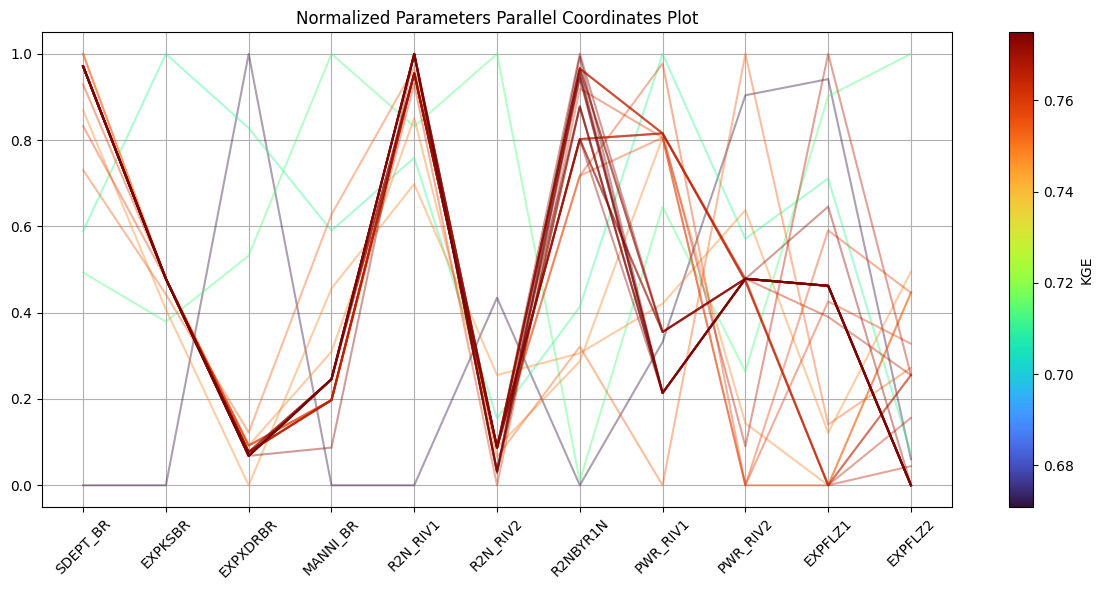

In [49]:
import numpy as np

fig, ax = parallel_plot(
    "/scratch/zelalem/cantrans-models/Calibration/old_cal/xxcalibration_07_2_polish_grouped/dds_status.out",
    columns=["SDEPT_BR", "EXPKSBR ", "EXPXDRBR", "MANNI_BR", 
             "R2N_RIV1", "R2N_RIV2", "R2NBYR1N", "PWR_RIV1", "PWR_RIV2", "EXPFLZ1 ", "EXPFLZ2"
    ],
    color_column="OBJ_FUNCTION",
    color_label="KGE",
    cmap="turbo",
    alpha=0.4,
    obj_transform=lambda x: 2 + (1 / (x + 1e-12)),   # recover KGE
    save_path="parallel_coordinates_kge.png"
)

plt.show()